In [1]:
import geomodel_toolbox
import importlib

importlib.reload(geomodel_toolbox)

Setting Backend To: AvailableBackends.numpy


<module 'geomodel_toolbox' from 'c:\\Users\\ethan\\MSc-Thesis\\GeoModel\\geomodel_toolbox.py'>

In [2]:
import numpy as np
import pandas as pd

In [3]:
#  ====
# Inputs for creating strat model with gempy
#  ====

x_lims = (369702.8, 374398.9)
y_lims = (407778.9, 411690.2)
z_lims = (350, -2000)

resolution = [100, 100, 60]   # nx, ny, nz
 
strat_azimuth = 135 #deg
strat_dip = 10 #deg

#  ====
# Inputs for fracture map
#  ====

aperture = [50, 50] #[m] [MEAN, STD]
radius = [1000, 100] #[m] [MEAN, STD]
azimuth = [45, 10] #[deg] [MEAN, STD]

density = 5e-9 #[fractures/m3]

In [4]:
#geomodel_toolbox.create_strat_model(x_lims, y_lims, z_lims, resolution, strat_azimuth, strat_dip)

c:\Users\ethan\MSc-Thesis\GeoModel\geomodel_toolbox.py:304: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


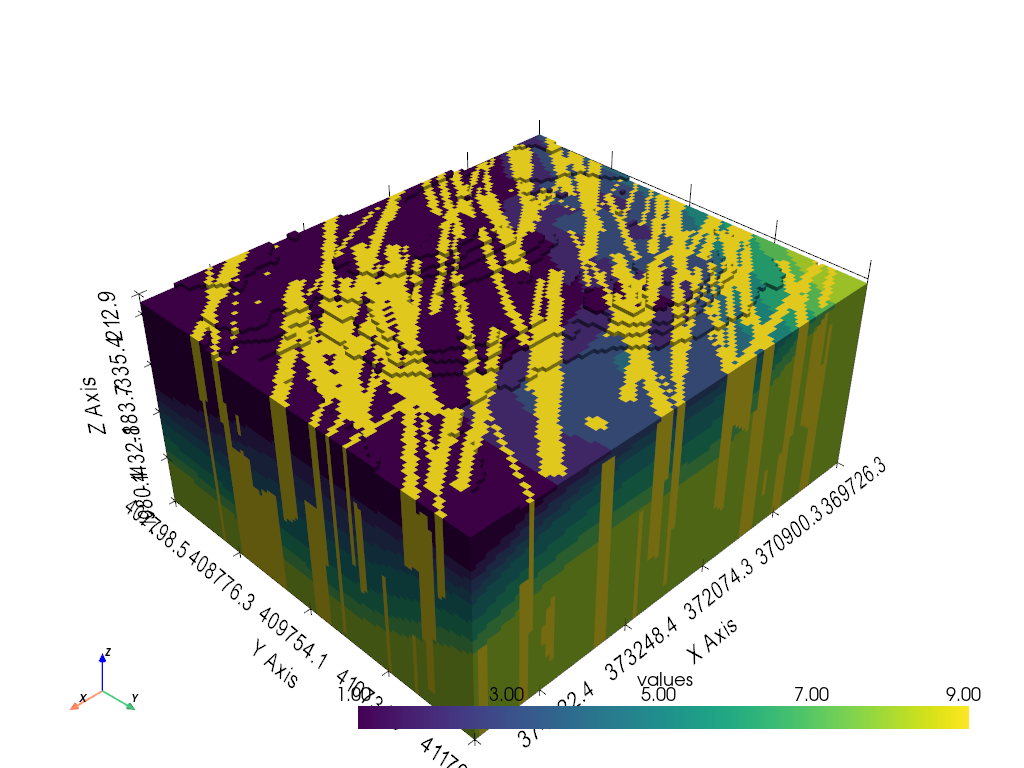

In [5]:
# Import previously defined topo+strat model
lith_topo, x_array, y_array, z_array= geomodel_toolbox.import_strat_model(show_plot=False)

# Generate fracture model based on inputs
mask, df = geomodel_toolbox.generate_fracture_model(x_array, y_array, z_array, aperture, radius, azimuth, density, show_plot=False)

# Combine to get topo+strat+frac model
geomodel = lith_topo.copy()
geomodel[(lith_topo > 0) & mask] = lith_topo.max()+1

# Plot results
geomodel_toolbox.plot_3d_model(geomodel, x_array, y_array, z_array)

In [6]:
import darts_helper
importlib.reload(darts_helper)

ROCK_PROPS = {
    1: {"poro": 0.2, "permx": 50},      # top
    2: {"poro": 0.02, "permx": 1e-2},   # B1
    3: {"poro": 0.2, "permx": 50},      # M1
    4: {"poro": 0.02, "permx": 1e-2},   # B2
    5: {"poro": 0.2, "permx": 50},      # M2
    6: {"poro": 0.02, "permx": 1e-2},   # B3
    7: {"poro": 0.2, "permx": 50},      # M3
    8: {"poro": 0.02, "permx": 1e-2},   # B4
    9: {"poro": 0.1, "permx": 1e3},     # faults
}
darts_helper.model_to_grdecl(geomodel, x_array, y_array, z_array, ROCK_PROPS)

well_data = pd.read_csv('gempy_inputs/borehole_data.csv')
darts_helper.wells_to_compdat(well_data, x_array, y_array, z_array)

Written: reservoir.grdecl
Grid dimensions: 100 x 100 x 60
Total cells: 600,000
Active cells: 518,499
Inactive air cells: 81,501

Written: properties.in

Written: well_data.inc


c:\Users\ethan\MSc-Thesis\GeoModel\geomodel_toolbox.py:304: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


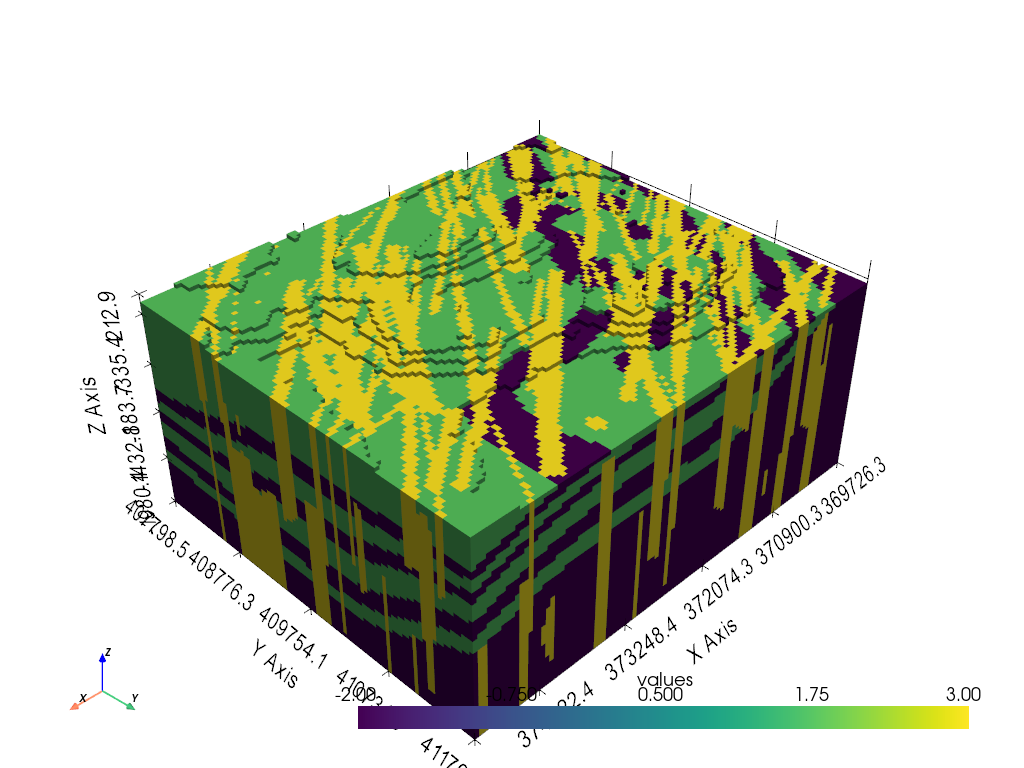

In [7]:
# Lookup table for values 0–9
permx_lookup = np.zeros(10)
for k, v in ROCK_PROPS.items():
    permx_lookup[k] = v["permx"]

# Map rock IDs to permx
permx_array = permx_lookup[geomodel]

geomodel_toolbox.plot_3d_model(permx_array, x_array, y_array, z_array, scale='log')